In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import scipy.integrate as integrate

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
DP = DP()
FIT = FitSpectrum()
dps_df, _, _, _ = DP.extract_fits_data('./catalogs/0310_dps.fits')

In [4]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list())
DP_SPECTRA = DP_SPECTRA.stack_data()
DP_SPECTRA = DP_SPECTRA.shift_to_rest_frame()

In [56]:
example_id = 39627793872454641
example_idx = DP_SPECTRA.id2index(example_id)
lam, flux, ivar = DP_SPECTRA.data_stack[example_idx, 0, :], DP_SPECTRA.data_stack[example_idx, 1, :], DP_SPECTRA.data_stack[example_idx, 2, :]
sigma = 1/np.sqrt(np.abs(ivar))

/var/folders/_b/sl_t4k5539781f29qf723b080000gn/T/ipykernel_68430/3014035987.py:4: RuntimeWarning: divide by zero encountered in divide
  sigma = 1/np.sqrt(np.abs(ivar))


In [57]:
display(DP_SPECTRA.df.iloc[example_idx])

TARGETID    39627793872454641
RA                 185.039425
DEC                  0.357117
SPECTYPE               GALAXY
LOGM                      0.0
LOGSFR                    0.0
z_pipe               0.241818
z                    0.241818
Name: 16312, dtype: object

In [58]:
line_cols = ['OII3729', 'OII3726',
            'Hbeta',
            'OIII5007', 'OIII4959',
            'Halpha', 'NII6583', 'NII6548',
            'SII6731', 'SII6716']

In [59]:
params_1comp, _, _, _ = FIT.fit_multi_emission_vel(data_class=DP_SPECTRA, id=example_id, two_component=False, w_dz=False)

model_1comp = []
lams_1comp = []
for i, (amp, lam0) in enumerate(zip(params_1comp['amps'], params_1comp['lam0s'])):
    for j in range(len(amp)):
        model_1comp.append(model_vel(lam, gaussian_parms=[(amp[j], lam0[j], 0, params_1comp['sigma'])]))
        lams_1comp.append(lam0[j])

integrated_flux_1comp = integrate.trapezoid(np.array(model_1comp), x=np.array(lam))
df_1comp = pd.DataFrame({'line': line_cols, 'lam0': lams_1comp, 'flux_1comp': integrated_flux_1comp})

In [60]:
params_2comp, _, _, _ = FIT.fit_multi_emission_vel(data_class=DP_SPECTRA, id=example_id, two_component=True, w_dz=False)

model_2compL = []
lams_2compL = []
for i, (amp, lam0) in enumerate(zip(params_2comp['left_amps'], params_2comp['left_lam0s'])):
    for j in range(len(amp)):
        model_2compL.append(model_vel(lam, gaussian_parms=[(amp[j], lam0[j], params_2comp['dv_l'], params_2comp['sigma_l'])]))
        lams_2compL.append(lam0[j])

integrated_flux_2compL = integrate.trapezoid(np.array(model_2compL), x=np.array(lam))
df_2compL = pd.DataFrame({'lam0': lams_2compL, 'flux_2compL': integrated_flux_2compL})

model_2compR = []
lams_2compR = []
for i, (amp, lam0) in enumerate(zip(params_2comp['right_amps'], params_2comp['right_lam0s'])):
    for j in range(len(amp)):
        model_2compR.append(model_vel(lam, gaussian_parms=[(amp[j], lam0[j], params_2comp['dv_r'], params_2comp['sigma_r'])]))
        lams_2compR.append(lam0[j])
integrated_flux_2compR = integrate.trapezoid(np.array(model_2compR), x=np.array(lam))
df_2compR = pd.DataFrame({'lam0': lams_2compR, 'flux_2compR': integrated_flux_2compR})

In [61]:
df = pd.merge(df_1comp, df_2compL, on='lam0', how='outer')
df = pd.merge(df, df_2compR, on='lam0', how='outer').sort_values(by='lam0').reset_index(drop=True)
df['flux_2comp'] = df['flux_2compL'] + df['flux_2compR']
# df.index = df['line']
# df.drop(columns=['line'], inplace=True)
df.head(10)

,line,lam0,flux_1comp,flux_2compL,flux_2compR,flux_2comp
0,OII3726,3727.091749,21.470562,21.103390,0.309888,21.413278
1,OII3729,3729.875470,28.577176,28.088471,0.045549,28.134021
2,Hbeta,4862.691040,13.711726,9.472384,1.099618,10.572002
3,OIII4959,4960.294948,6.863913,4.496190,0.589149,5.085339
4,OIII5007,5008.239686,20.790771,13.618948,2.401518,16.020466
5,NII6548,6549.859028,3.917094,3.586968,0.119192,3.706161
6,Halpha,6564.631999,49.396831,42.654934,1.924825,44.579759
7,NII6583,6585.278548,12.011744,10.999415,0.368623,11.368038
8,SII6716,6718.294313,16.625301,13.357041,1.305828,14.662869
9,SII6731,6732.668179,11.791904,10.033690,0.614644,10.648334


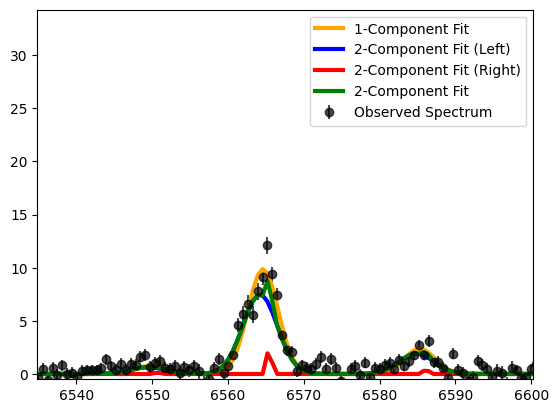

In [62]:
plt.errorbar(lam, flux, yerr=sigma, label='Observed Spectrum', fmt='o', color='k', alpha=0.7)
plt.plot(lam, np.sum(model_1comp, axis=0), label='1-Component Fit', color='orange', linewidth=3)
plt.plot(lam, np.sum(model_2compL, axis=0), label='2-Component Fit (Left)', color='blue', linewidth=3)
plt.plot(lam, np.sum(model_2compR, axis=0), label='2-Component Fit (Right)', color='red', linewidth=3)
plt.plot(lam, np.sum(model_2compL, axis=0)+np.sum(model_2compR, axis=0), label='2-Component Fit', color='green', linewidth=3)
plt.xlim((NII_rest[0]-15, NII_rest[1]+15))
plt.ylim(bottom=-0.5)
plt.legend()
plt.show()

In [63]:
print(df.iloc[6]['flux_1comp'])

49.39683058988725


In [64]:
def sfr(flux_halpha, flux_hbeta, z):
    """
    the unit of the flux is:
    1e-17 * erg / cm^2 / s
    """
    
    ebv = 1.97 * np.log10((flux_halpha/flux_hbeta) / 2.86)
    A_halpha = 3.33 * ebv
    flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17
    flux_adjusted = flux_intrinsic * (1+z)
    
    luminous_distance = cosmo.luminosity_distance(z).to('cm').value
    lum_halpha = 4 * np.pi * (luminous_distance**2) * flux_adjusted
    sfr = 5.5e-42 * lum_halpha
    return sfr

In [65]:
sfr_1comp = sfr(df.iloc[6]['flux_1comp'], df.iloc[2]['flux_1comp'], DP_SPECTRA.df.iloc[example_idx]['z'])
print(f' 1Comp: {np.log10(sfr_1comp)}')

sfr_2compL = sfr(df.iloc[6]['flux_2compL'], df.iloc[2]['flux_2compL'], DP_SPECTRA.df.iloc[example_idx]['z'])
print(f'2CompL: {np.log10(sfr_2compL)}')

sfr_2compR = sfr(df.iloc[6]['flux_2compR'], df.iloc[2]['flux_2compR'], DP_SPECTRA.df.iloc[example_idx]['z'])
print(f'2CompR: {np.log10(sfr_2compR)}')

sfr_2comp = sfr(df.iloc[6]['flux_2comp'], df.iloc[2]['flux_2comp'], DP_SPECTRA.df.iloc[example_idx]['z'])
print(f' 2Comp: {np.log10(sfr_2comp)}')
print(f' 2Comp: {np.log10(sfr_2compL + sfr_2compR)}')

print(f'Cigale: {DP_SPECTRA.df.iloc[example_idx]['LOGSFR']}')

 1Comp: 0.06493586821421832
2CompL: 0.2554834902450712
2CompR: -2.1668975525117817
 2Comp: 0.19978935061592434
 2Comp: 0.2571225074115027
Cigale: 0.0
